In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions_glitterin"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Make a function to save the information to the df

In [3]:
def make_fit_summary_row(fit_name, sf_results, nk):
    return {
        "Fit Case": fit_name,
        "nk": nk,
        "Scale Factor": sf_results["best_sf"],
#         "Best amax (cm)": sf_results["best_rvol_max_cm"],
        "Best amax (micron)": sf_results["best_rvol_max_micron"],
        "Best Index": sf_results["best_idx_arr"],
    }

rows_DSHARP = []

# Set variables and run glitterin

In [4]:
# Constants
BandsIndex = ["Band 4 nterms2", "Band 5", "Band 5 robust -1", "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2', 'Band5', "Band5_robust_minus1", 'Band6', 'Band7_nterms2']
# BandLabelsForPlots = ['Band 4', 'Band 5', 'Band 6', 'Band 7']

num_bands = len(BandsIndex)
 
lambda_bands_cm = {
    b: mm_to_cm(lambda_mm[b]) 
    for b in BandsIndex
}


# band_colors = [alma_band_colors[b] for b in BandsIndex]

In [5]:
# Load in POLF
df_POLF = load_POLF(BandsIndex, print_things = True)

Band = Band 4 nterms2
Band = Band 5
Band = Band 5 robust -1
Band = Band 6
Band = Band 7 nterms2
 in load_POLF, results = {'Band': ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], 'POLF_Gaussian': [np.float64(1.1877280000000001), np.float64(0.9329613999999999), np.float64(1.3769860999999999), np.float64(1.4453122), np.float64(0.8302132)], 'POLF_maxPOLI': [np.float64(1.561384), np.float64(1.0520775), np.float64(1.5137895000000001), np.float64(1.4862873), np.float64(1.0841521)], 'POLF_maxStokesI': [np.float64(1.3677061000000001), np.float64(0.9908963), np.float64(1.4034492), np.float64(1.4639224), np.float64(1.0421403)]}


In [6]:
# Choose the array of a_max values we are looking at 
# Figure 12 in in 2025 has 1e-3 to 1e0 cm # This corresponds to 10 to 10000 micron 
max_rvol_grid_cm = np.logspace(-3, 0, 1000) 



nk_data = np.genfromtxt(
    "nk_values.txt",
    dtype=None,
    names=True,
    encoding=None
)

data_n = {}
data_k = {}

for b, b_file in zip(BandsIndex, bands_naming):
    row = nk_data[nk_data["band"] == b_file][0]
    
    data_n[b] = float(row["n"])
    data_k[b] = float(row["k"])

In [7]:
# results = RunGlitterinPowerLawDistAveraged(BandsIndex, lambda_bands_cm, data_n, data_k, max_rvol_grid_cm)

# np.savez("results_glitterin.npz", results=results)

In [8]:
data = np.load("results_glitterin.npz", allow_pickle=True)
results = data["results"].item()

# P vs omega vs maximum grain size plot

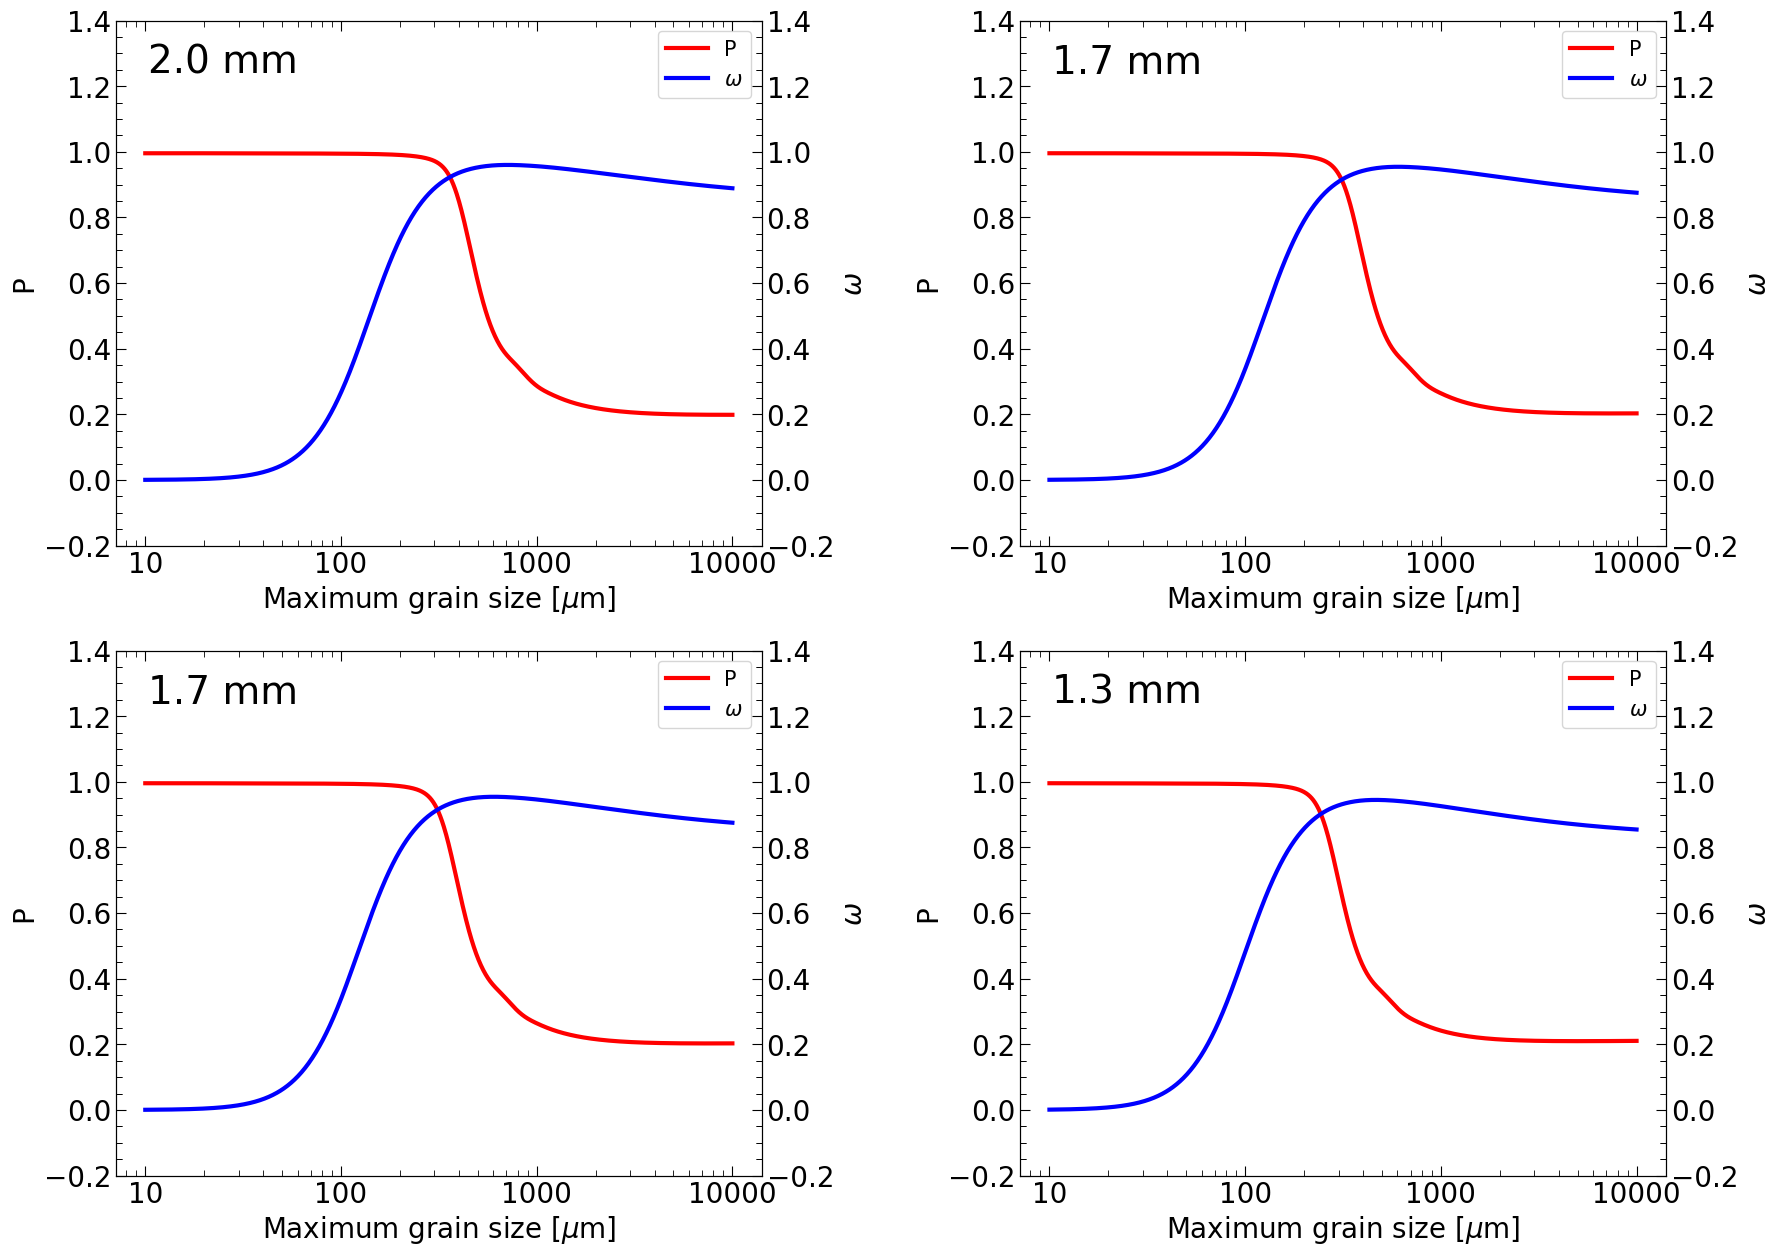

In [9]:
fig, ax = P_vs_omega_twin_axis(results, BandsIndex, lambda_bands_cm)

# P$\omega$ vs maximum grain size

Band 4 nterms2
Band 5
Band 5 robust -1
Band 6
Band 7 nterms2


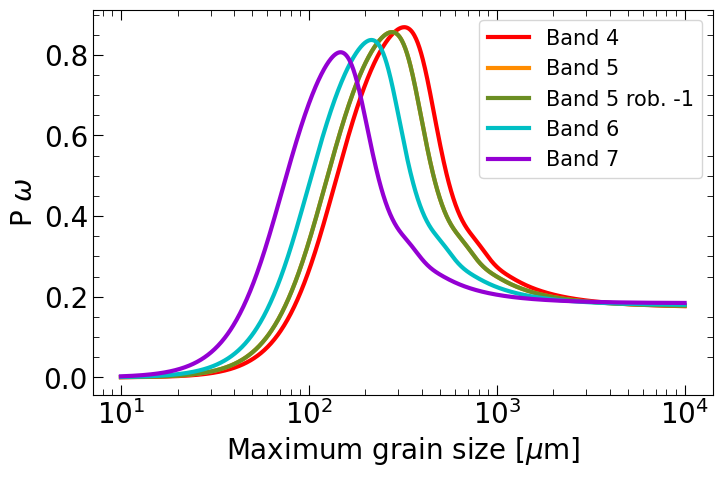

In [10]:
fig, ax = Pomega_Plot(results, BandsIndex)

# P$\omega$ vs maximum grain size, with scale factor

In [11]:
POLF_index = 'max Stokes I'

In [12]:
def plot_scale_factor_resultsGlitterin(bands,
                                       bands_included_in_fit, 
                                       results, 
                                       sf_results, 
                                       df_POLF, 
                                       fig_x_size = 8,
                                       fig_y_size = 5,
                                       plot_sf = 1,
                                       custom_lw = None,
                                       chi_sq_precision = 4,
                                       band_label_fs = 15,
                                       marker_legend_size = 15,
                                      for_poster = False,
                                      poster_scale = 1):
    
    # Change sizes of things if for_poster or not
    # ---------------------------
    if for_poster:
        axisnum_fs = poster_axis_num_fs* poster_scale
        xy_axis_fs = poster_axis_label_fs * poster_scale
        stats_fs = poster_text2_fs * poster_scale
        band_label_fs = poster_colour_bands_fs * poster_scale
        marker_legend_size = poster_colour_bands_legend_ms * poster_scale**2 * 1.1
        marker_size = poster_colour_bands_ms * poster_scale**2
        bands_labels = ['Band 4', 'Band 5 robust -1', 'Band 6', 'Band 7']
        legend_bands = ['Band 4', 'Band 5 robust -1', 'Band 6', 'Band 7']
    # ---------------------------
    else: 
        axisnum_fs = axis_num_fs*plot_sf
        xy_axis_fs = axis_label_fs * plot_sf
        stats_fs = 15
        #band_label_fs = 15
        marker_size = 100
        bands_labels = ['Band 4', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7']
        legend_bands = ['Band 4', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7']
    # ---------------------------
    
    
    sf = sf_results['best_sf']
    rvol_max_best_micron = sf_results['best_rvol_max_micron']
    
    

    # ----------------------------------------------------------------
    band_ls = [
    '-' if b in bands_included_in_fit else '--'
    for b in bands
    ]
    
#     if custom_lw is None:
#         # default behavior
#         bands_lw = [
#             3 if b in bands_included_in_fit else 2
#             for b in bands
#         ]
#     else:
#         # override where specified
#         bands_lw = [
#             custom_lw.get(b, 3 if b in bands_included_in_fit else 2)
#             for b in bands
#         ]
    # Set default line widths
    # ------------------------------------------------
    if for_poster:
        included_lw = poster_lw * poster_scale
    else:
        included_lw = 5

    excluded_lw = included_lw * (2/3)

    if custom_lw is None:
        bands_lw = [
            included_lw if b in bands_included_in_fit else excluded_lw
            for b in bands
        ]
    else:
        bands_lw = [
            custom_lw.get(
                b,
                included_lw if b in bands_included_in_fit else excluded_lw
            )
            for b in bands
        ]
    # ------------------------------------------------

    # ----------------------------------------------------------------
    # Set the colors and marker size for each band 
    # ----------------------------------------------------------------
    band_colors = []
    ms = []

    for b in bands:

        if for_poster and b == "Band 5 robust -1":
            band_colors.append(alma_band_colors["Band 5"])
            ms.append(constants.alma_band_ms["Band 5"])

        else:
            band_colors.append(alma_band_colors[b])
            ms.append(constants.alma_band_ms[b])
    # ----------------------------------------------------------------
    
    
    # Get POLF values
    # ----------------------------------------------------------------
    POLF_markers = dict(zip(df_POLF["Band"], df_POLF["POLF_maxStokesI"]))
    # ----------------------------------------------------------------
    
    
    # Make the figure
    # Later I will make this so you can customize how many figures you need
    fig, ax = plt.subplots(figsize=(fig_x_size, fig_y_size))
    
    # Axes
    # ----------------------------------------------------------------
    # Make x-axis log
    ax.set_xscale('log')
    
    # Label the x- and y-axis labels
    ax.set_ylabel('P $\omega$', fontsize = xy_axis_fs)
    ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize = xy_axis_fs)
    
    # Adjust ticks
    # ------------------------
    if for_poster:
        add_min_major_ticks(ax, axis_num_fs = axisnum_fs)
        

    else:
        add_min_major_ticks(ax) 
    # ------------------------

    # ----------------------------------------------------------------
    

    # Set the x-axis values
     # ----------------------------------------------------------------
    rvol_max_micron = results[bands[0]]['rvol_max_micron']
     # ----------------------------------------------------------------
    


    marker_handles = []
    
    # Loop over each band 
    for j, b in enumerate(bands):

        idx = bands.index(b)

        # Set the face and edge color of the POLF markers
        fc = constants.alma_band_colors[b]
        ec = constants.alma_band_colors[b]
        marker_lw = 0 

        # For poster: make Band 5 robust -1 look like Band 5
        if for_poster and b == "Band 5 robust -1":
            fc = constants.alma_band_colors["Band 5"]
            ec = constants.alma_band_colors["Band 5"]

        # Normal Band 5 is hollow only when NOT poster
        if b == "Band 5" and not for_poster:
            fc = 'none'
            marker_lw = 5
        # ---------------------------------------------------
        # Plot the POLF values at the best amax
        # Plot marker?
        plot_marker = True

        if for_poster and b == "Band 5":
            plot_marker = False

        if plot_marker:
            ax.scatter(
                rvol_max_best_micron,
                POLF_markers[b],
                marker=ms[j],
                s=marker_size,
                facecolors=fc,
                edgecolors=ec,
                linewidths=marker_lw
            )
        # ---------------------------------------------------


        marker_handles.append(
        Line2D([0], [0],
               marker=ms[j],
               color='none',
               markerfacecolor=fc,
               markeredgecolor=ec,
               markeredgewidth=marker_lw,
               markersize=15,
               linestyle='None'))

        # Plot rvol_max grid and P omega multiplied by the scale factor
        # ---------------------------------------------------
        if b not in ["Band 5 robust -1", "Band 5 robust -2"]:
            print(f'[{constants.alma_band_plot_labels[b]}]')
            ax.plot(rvol_max_micron,
                    results[b]['P_omega'] * sf,
                       color=band_colors[j],
                       #label= f'{constants.alma_band_plot_labels[b]}',
                       lw=bands_lw[j],
                       ls=band_ls[j]
                      )
        # ---------------------------------------------------
    
        # Calculate chi_sq
        # ---------------------------------------------
        chi_sq_running_sum = 0

        best_idx = sf_results['best_idx_arr']

        for b in bands:

            # optional: skip Band 5 if you want
            if b == "Band 5":
                continue

            POLF_obs = POLF_markers[b]
            POLF_model = results[b]['P_omega'][best_idx] * sf

            chi_sq_running_sum += (POLF_obs - POLF_model)**2

        chi_sq = chi_sq_running_sum
        # ---------------------------------------------
        
        
        
                
    x_pos = 0.4 
    y_pos = 0.05
    y_gap = 0.1
        
        

    ax.text(x_pos, y_pos + y_gap,  f'$\chi^2$ = {chi_sq:.{chi_sq_precision}f}', transform=ax.transAxes, fontsize = stats_fs)


    if for_poster == False:
        ax.text(x_pos, y_pos + 2*y_gap, f'sf = {sf:.2f}', transform=ax.transAxes, fontsize = stats_fs)

    # Add the a_max to the text
    ax.text(x_pos, y_pos, rf'$a_{{\mathrm{{max}}}}$ = {rvol_max_best_micron:.0f} $\mu$m', 
               transform=ax.transAxes, 
               fontsize = stats_fs)
        
        
        
    
    
    # Add coloured text for each Band 
    # ----------------------------------------------------
    start = 0.9 # y
    c = 0
    marker_legend_handles = []
    # Loop over each band 
    for j, b_label in enumerate(bands_labels):
        

        if for_poster and b_label == "Band 5 robust -1":
            label = "Band 5"

        elif "robust" in b_label:
            label = b_label.replace(" robust ", "\nrob. ")
            c = c + 0.075

        else:
            label = b_label

#         ax.text(0.01, start - c,
#                    label,
#                    transform=ax.transAxes,
#                    fontsize=15,
#                    color=band_colors[j])
        
        if for_poster and b_label == "Band 5 robust -1":
            color = alma_band_colors["Band 5"]
            marker = constants.alma_band_ms["Band 5"]

        elif b_label == "Band 6":
            color = alma_band_colors["Band 6"]
            marker = constants.alma_band_ms["Band 6"]

        elif b_label == "Band 7":
            color = alma_band_colors["Band 7"]
            marker = constants.alma_band_ms["Band 7"]

        else:
            color = alma_band_colors[b_label]
            marker = constants.alma_band_ms[b_label]

        handle = Line2D(
            [0], [0],
            marker=marker,
            color='none',
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=marker_legend_size,
            linestyle='None',
            label=label
        )
            
        c = c + 0.1
        marker_legend_handles.append(handle)
        # ----------------------------------------------------

    
    
    # Add a legend for the POLF markers
    # ----------------------------------------------------
    ax.legend(handles=marker_handles, 
                 fontsize = 15, 
                 frameon=False, 
#                  title="Obs. POLF", 
                 title_fontsize = 15,
                 loc = 'upper right',
                 handletextpad=-3.8,
                 handlelength=0.2)   
    # ----------------------------------------------------
    
    
    
    # Add the names of the bands in the correct colour
    # ----------------------------------------------------
    legend = ax.legend(
        handles=marker_legend_handles,
        fontsize = band_label_fs,
        frameon=False,
        loc='upper right',
        handletextpad=0.5, # Cotrols distance between marker and text 
        handlelength=1, # Cotrols distance between marker and text 
        labelspacing=0.6 # Controls vertical gap between the markers
    )
    
    legend_colors = [
        alma_band_colors["Band 4"],
        alma_band_colors["Band 5"],
        alma_band_colors["Band 6"],
        alma_band_colors["Band 7"]
    ]

    for text, color in zip(legend.get_texts(), legend_colors):
        text.set_color(color)
    # ----------------------------------------------------


#     fig.subplots_adjust(
#         left=0.15,
#         right=0.97,
#         bottom=0.18,
#         top=0.95
#     )



    return fig, ax
    

# --------------------------------------------------------------------------------------

In [13]:
poster_x_cm = 27.2
poster_y_cm = 16.65

current_figx = 7
current_slides_x_cm = 46.88

# Get figx from width only
figx = current_figx * poster_x_cm / current_slides_x_cm

# Force correct aspect ratio
figy = figx * (poster_y_cm / poster_x_cm)

print(figx, figy)

print(rf"My poster scale is: {poster_scale}")
# --------------------------------------------------------------------------------------

BandsInFit_all = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]


sf_results_all = find_sf_glitterin(results, BandsIndex, BandsInFit_all, df_POLF, POLF_index)

fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_all, results, sf_results_all, df_POLF,
                                            for_poster = True, 
                                             fig_x_size = figx, fig_y_size = figy,
                                            poster_scale = 0.35)

rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "All",
        sf_results = sf_results_all,
        nk = 'DSHARP',
    )
)

fig.subplots_adjust(
    left=0.15,
    right=0.96,
    bottom=0.2,
    top=0.94
)


plt.savefig(image_folder_path + '/POSTER/' + "BestGlitterinPw.png", 
            dpi=300, 
            #bbox_inches='tight',
            facecolor='white')

4.061433447098976 2.486134812286689


NameError: name 'poster_scale' is not defined

In [ ]:
# raise SystemExit("Stop here")

In [ ]:
BandsInFit_wo5 = ["Band 4 nterms2", "Band 6", "Band 7 nterms2"]


sf_results_wo5 = find_sf_glitterin(results, BandsIndex, BandsInFit_wo5, df_POLF, POLF_index)

fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_wo5, results, sf_results_wo5, df_POLF,
                                            chi_sq_precision=4)


rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "No 5",
        sf_results = sf_results_wo5,
        nk = 'DSHARP',
    )
)

In [ ]:
BandsInFit_wo6 = ["Band 4 nterms2", "Band 5 robust -1",  "Band 7 nterms2"]


sf_results_wo6 = find_sf_glitterin(results, BandsIndex, BandsInFit_wo6, df_POLF, POLF_index)

fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_wo6, results, sf_results_wo6, df_POLF)


rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "No 6",
        sf_results = sf_results_wo6,
        nk = 'DSHARP',
    )
)

In [ ]:
BandsInFit_just47 = ["Band 4 nterms2",  "Band 7 nterms2"]


sf_results_just47 = find_sf_glitterin(results, BandsIndex, BandsInFit_just47, df_POLF, POLF_index)

fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_just47, results, sf_results_just47, df_POLF)

rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "47",
        sf_results = sf_results_just47,
        nk = 'DSHARP',
    )
)

# Testing Other Dust Things

## Hematite

In [ ]:
# fname = 'size_hematite.txt'
# sizes = read_gals_size_table(fname, skiprows=2, out_type='container')


data_n_Feldspar = {
    'Band 4 nterms2': 1.5,
    'Band 5': 1.5,
    'Band 5 robust -1': 1.5,
    'Band 6': 1.5,
    'Band 7 nterms2': 1.5
}

data_k_Feldspar = {
    'Band 4 nterms2': 1e-4,
    'Band 5': 1e-4,
    'Band 5 robust -1': 1e-4,
    'Band 6': 1e-4,
    'Band 7 nterms2': 1e-4
}


In [ ]:
# max_rvol_grid_cm = np.logspace(-3, 0, 100) 

# resultsFeldspar = RunGlitterinPowerLawDistAveraged(BandsIndex, 
#                                                    lambda_bands_cm, 
#                                                    data_n_Feldspar, 
#                                                    data_k_Feldspar,
#                                                    max_rvol_grid_cm)

# np.savez("results_glitterinFeldspar.npz", results=resultsFeldspar)

In [ ]:
data = np.load("results_glitterinFeldspar.npz", allow_pickle=True)

resultsFeldspar = data["results"].item()


# Testing Feldspar
rows_Feldspar = []


# All bands
# ---------------------------------------------------------------------------------------------------
sf_results_all = find_sf_glitterin(resultsFeldspar, BandsIndex, BandsInFit_all, df_POLF, POLF_index)

rows_Feldspar.append(
    make_fit_summary_row(
        fit_name = "All",
        sf_results = sf_results_all,
        nk = 'Feldspar',
    )
)
# ---------------------------------------------------------------------------------------------------

# Without 5
# ---------------------------------------------------------------------------------------------------
sf_results_wo5 = find_sf_glitterin(resultsFeldspar, BandsIndex, BandsInFit_wo5, df_POLF, POLF_index)


rows_Feldspar.append(
    make_fit_summary_row(
        fit_name = "No 5",
        sf_results = sf_results_wo5,
        nk = 'Feldspar',
    )
)
# ---------------------------------------------------------------------------------------------------
# Without 6
# ---------------------------------------------------------------------------------------------------

sf_results_wo6 = find_sf_glitterin(resultsFeldspar, BandsIndex, BandsInFit_wo6, df_POLF, POLF_index)



rows_Feldspar.append(
    make_fit_summary_row(
        fit_name = "No 6",
        sf_results = sf_results_wo6,
        nk = 'Feldspar',
    )
)
# ---------------------------------------------------------------------------------------------------

# Just 4 and 7 

# ---------------------------------------------------------------------------------------------------
sf_results_just47 = find_sf_glitterin(resultsFeldspar, BandsIndex, BandsInFit_just47, df_POLF, POLF_index)

rows_Feldspar.append(
    make_fit_summary_row(
        fit_name = "47",
        sf_results = sf_results_just47,
        nk = 'Feldspar',
    )
)
# ---------------------------------------------------------------------------------------------------

## Feldspar (THESE ARE SWAPPED)

In [ ]:
data_n_Hematite= {
    'Band 4 nterms2': 3,
    'Band 5': 3,
    'Band 5 robust -1': 3,
    'Band 6': 3,
    'Band 7 nterms2': 3
}

data_k_Hematite = {
    'Band 4 nterms2': 0.03,
    'Band 5': 0.03,
    'Band 5 robust -1': 0.03,
    'Band 6': 0.03,
    'Band 7 nterms2': 0.03
}

In [ ]:
# max_rvol_grid_cm = np.logspace(-3, 0, 100) 


# resultsHematite = RunGlitterinPowerLawDistAveraged(BandsIndex, 
#                                                    lambda_bands_cm, 
#                                                    data_n_Hematite, 
#                                                    data_k_Hematite, 
#                                                    max_rvol_grid_cm)

# np.savez("results_glitterinHematite.npz", results=resultsHematite)

In [ ]:
data = np.load("results_glitterinHematite.npz", allow_pickle=True)

resultsHematite = data["results"].item()

# Testing Hematite
rows_Hematite = []


# All bands
# ---------------------------------------------------------------------------------------------------
sf_results_all = find_sf_glitterin(resultsHematite, BandsIndex, BandsInFit_all, df_POLF, POLF_index)

rows_Hematite.append(
    make_fit_summary_row(
        fit_name = "All",
        sf_results = sf_results_all,
        nk = 'Hematite',
    )
)
# ---------------------------------------------------------------------------------------------------

# Without 5
# ---------------------------------------------------------------------------------------------------
sf_results_wo5 = find_sf_glitterin(resultsHematite, BandsIndex, BandsInFit_wo5, df_POLF, POLF_index)


rows_Hematite.append(
    make_fit_summary_row(
        fit_name = "No 5",
        sf_results = sf_results_wo5,
        nk = 'Hematite',
    )
)
# ---------------------------------------------------------------------------------------------------
# Without 6
# ---------------------------------------------------------------------------------------------------

sf_results_wo6 = find_sf_glitterin(resultsHematite, BandsIndex, BandsInFit_wo6, df_POLF, POLF_index)



rows_Hematite.append(
    make_fit_summary_row(
        fit_name = "No 6",
        sf_results = sf_results_wo6,
        nk = 'Hematite',
    )
)
# ---------------------------------------------------------------------------------------------------

# Just 4 and 7 

# ---------------------------------------------------------------------------------------------------
sf_results_just47 = find_sf_glitterin(resultsHematite, BandsIndex, BandsInFit_just47, df_POLF, POLF_index)

rows_Hematite.append(
    make_fit_summary_row(
        fit_name = "47",
        sf_results = sf_results_just47,
        nk = 'Hematite',
    )
)
# ---------------------------------------------------------------------------------------------------

# Results

In [ ]:
df_DSHARP = pd.DataFrame(rows_DSHARP)

df_DSHARP

In [ ]:
df_Feldspar = pd.DataFrame(rows_Feldspar)

df_Feldspar

In [ ]:
df_Hematite = pd.DataFrame(rows_Hematite)

df_Hematite